# Null values to handle

- **Price** -> Has 40 null values (2%).
- **Discount** -> Has 40 null values (2%).
- **Payment Method** -> Has 1753 null values (87.65%)
- **Shipping Method** -> Has 1753 null values (87.65%)
- **Customer Age** -> Has 40 null values (2%).
- **Cupon Used** -> Has 1753 null values (87.65%)


In [ ]:
# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# System paths for module importing
import sys
sys.path.append('../')

# Custom utility functions
from src import null_values as nv 

# Machine Learning Imputation tools
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import KNNImputer, IterativeImputer

In [2]:
df_o=pd.read_csv('../data/data_cleaned.csv')

In [3]:
df=df_o.copy()

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           2000 non-null   int64  
 1   group             2000 non-null   object 
 2   visit_date        2000 non-null   object 
 3   conversion        2000 non-null   int64  
 4   product_category  2000 non-null   object 
 5   product_id        2000 non-null   int64  
 6   product_name      2000 non-null   object 
 7   quantity          2000 non-null   int64  
 8   price             1960 non-null   float64
 9   discount          1960 non-null   float64
 10  total_value       2000 non-null   float64
 11  payment_method    247 non-null    object 
 12  shipping_method   247 non-null    object 
 13  region            2000 non-null   object 
 14  customer_age      1960 non-null   float64
 15  customer_gender   2000 non-null   object 
 16  device            2000 non-null   object 


In [5]:
df.isnull().mean() *100

user_id              0.00
group                0.00
visit_date           0.00
conversion           0.00
product_category     0.00
product_id           0.00
product_name         0.00
quantity             0.00
price                2.00
discount             2.00
total_value          0.00
payment_method      87.65
shipping_method     87.65
region               0.00
customer_age         2.00
customer_gender      0.00
device               0.00
session_duration     0.00
coupon_used         87.65
browser              0.00
referral_source      0.00
conversion_str       0.00
dtype: float64

In [6]:
df_null_values=df.loc[:,df.isnull().sum()>0]
df_null_values

,price,discount,payment_method,shipping_method,customer_age,coupon_used
0,41.27,0.29,NaN,NaN,64.0,NaN
1,45.45,0.22,NaN,NaN,19.0,NaN
2,64.81,0.08,NaN,NaN,69.0,NaN
3,189.40,0.08,credit_card,express,53.0,no
4,19.82,0.19,NaN,NaN,18.0,NaN
...,...,...,...,...,...,...
1995,177.49,0.20,NaN,NaN,25.0,NaN
1996,109.75,0.20,NaN,NaN,58.0,NaN
1997,236.05,0.15,NaN,NaN,62.0,NaN
1998,22.67,0.11,NaN,NaN,46.0,NaN


### Null values categorical columns

In [7]:
for col in df_null_values.select_dtypes(include='O').columns:
  print(col.upper())
  display(df[col].value_counts()/df.shape[0]*100)
  print('----------')

PAYMENT_METHOD


payment_method
bank_transfer       3.65
credit_card         3.35
paypal              2.85
cash_on_delivery    2.50
Name: count, dtype: float64

----------
SHIPPING_METHOD


shipping_method
express     4.50
same_day    4.10
standard    3.75
Name: count, dtype: float64

----------
COUPON_USED


coupon_used
no     6.60
yes    5.75
Name: count, dtype: float64

----------


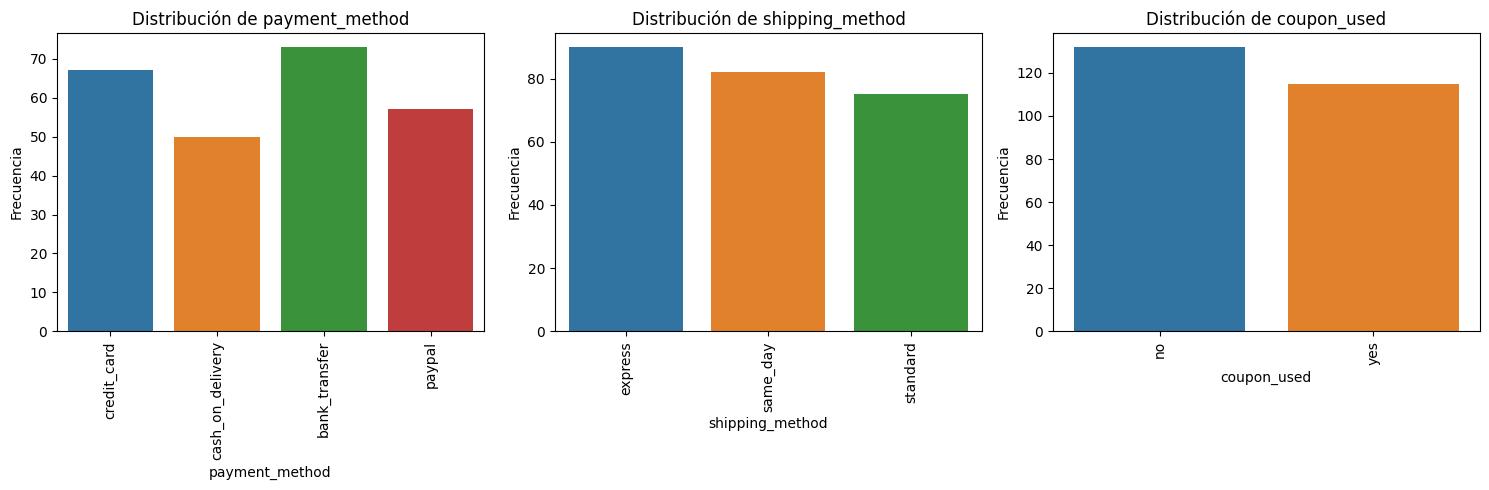

In [8]:
nv.subplot_col_cat(df_null_values)

In [9]:
df_null_values.select_dtypes(include='O').isnull().mean()*100

payment_method     87.65
shipping_method    87.65
coupon_used        87.65
dtype: float64

### It has been verified that the null values in the categorical columns are due to users not completing a purchase. Therefore, they naturally lack a payment method, shipping method, or applied coupon.

In [10]:
# Impute missing values in categorical columns with 'no_conversion'
df.loc[:,df.select_dtypes(include='O').columns]=df.select_dtypes(include='O').fillna('no_conversion')

In [11]:
df.isnull().mean()*100

user_id             0.0
group               0.0
visit_date          0.0
conversion          0.0
product_category    0.0
product_id          0.0
product_name        0.0
quantity            0.0
price               2.0
discount            2.0
total_value         0.0
payment_method      0.0
shipping_method     0.0
region              0.0
customer_age        2.0
customer_gender     0.0
device              0.0
session_duration    0.0
coupon_used         0.0
browser             0.0
referral_source     0.0
conversion_str      0.0
dtype: float64

# Outliers

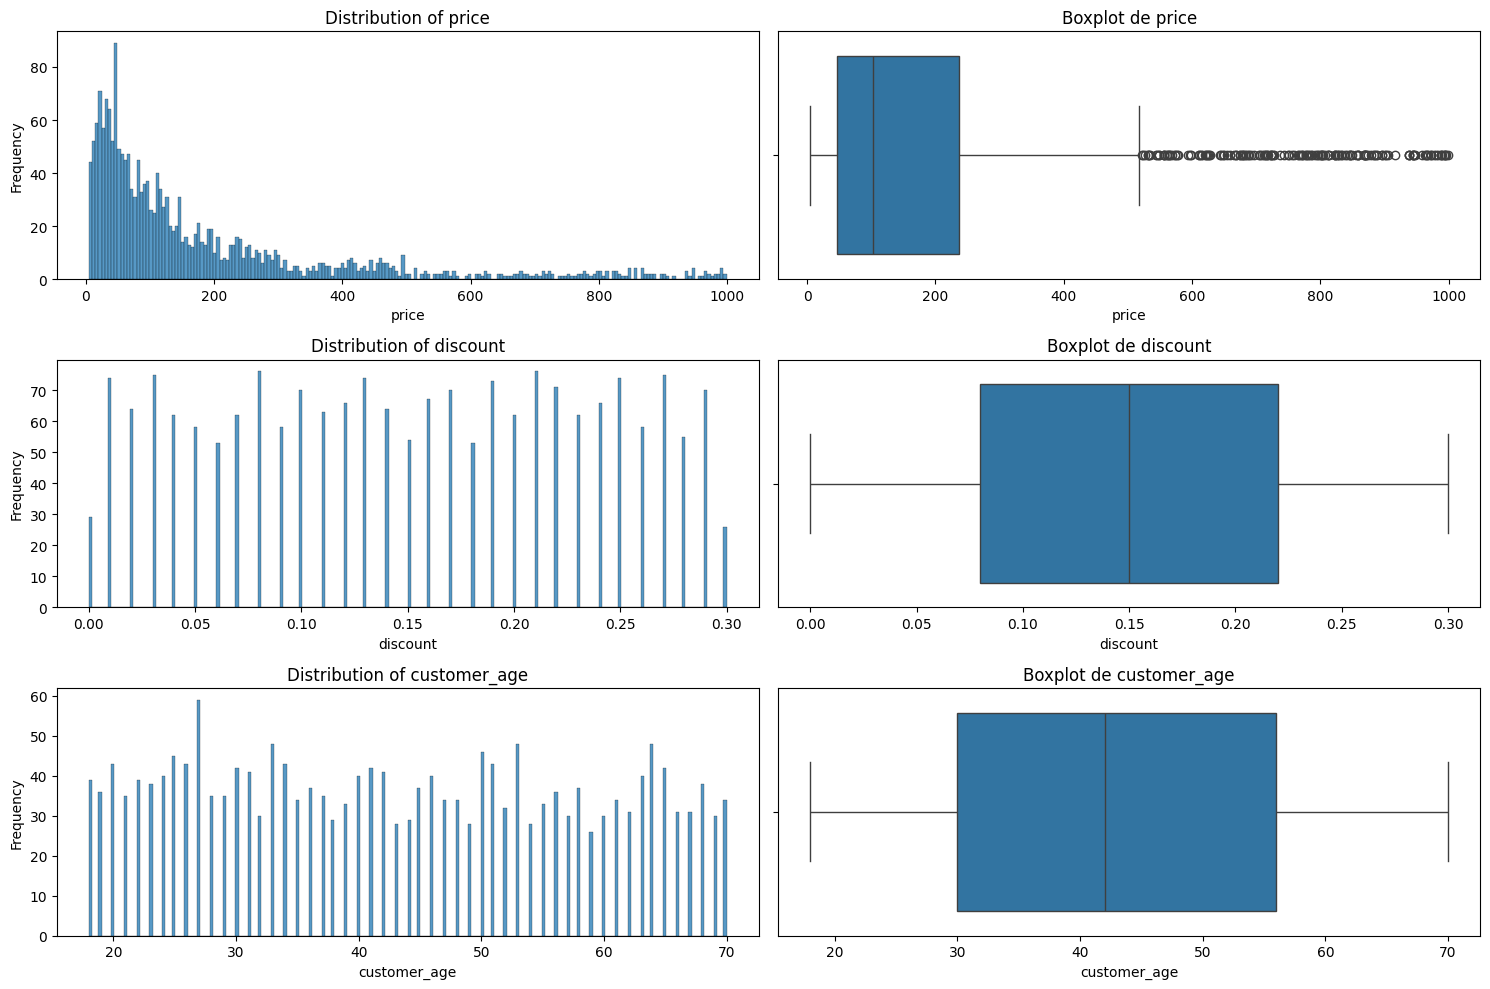

In [12]:
nv.subplot_col_num(df_null_values)

# Columns with outliers: 
  - Price
  - Total_value

In [13]:
q_75=df['price'].quantile(0.75)
q_25=df['price'].quantile(0.25)
itq_range=q_75-q_25

In [14]:
lower=q_25-(itq_range*1.5)
upper=q_75+(itq_range*1.5)

In [15]:
nv.calculate_outliers(df,['price','total_value'])

In the column PRICE we have a total of 161 outliers, representing 8.05 % of the total
In the column TOTAL_VALUE we have a total of 247 outliers, representing 12.35 % of the total


# Missing numeric values

In [16]:
df_null_values.select_dtypes(include='number').isnull().mean()*100

price           2.0
discount        2.0
customer_age    2.0
dtype: float64

In [17]:
df_null_values.describe().T

,count,mean,std,min,25%,50%,75%,max
price,1960.0,184.572138,211.981538,5.02,46.0925,102.465,236.155,998.88
discount,1960.0,0.150224,0.086591,0.00,0.0800,0.150,0.220,0.30
customer_age,1960.0,43.156633,15.361675,18.00,30.0000,42.000,56.000,70.00


- **discount**: As seen in the descriptive statistics, the mean (0.15) and median (0.15) are identical, indicating a perfectly symmetric distribution without outliers. Therefore, we use the mean for imputation.

- **customer_age**: The distribution is fairly uniform across age groups (no extreme outliers). However, following demographic data best practices and to maintain robustness against non-normal distributions, we use the median (42.0) to fill missing values.

In [18]:
df_filled_simple=df.fillna({'discount':df['discount'].mean(),
                            'customer_age':df['customer_age'].median()})

### Advanced Imputation: Handling missing 'price' using Machine Learning

Unlike age or discount, an item's price is highly dependent on other variables (like product category or total value). Using a simple mean would distort our data. Instead, we will test two advanced algorithms (Iterative Imputer and KNN Imputer) to predict and fill these missing values, and then compare which one preserves the original distribution better.

In [ ]:
df_filled_simple= nv.impute_iterative(df_filled_simple,['price'])
df_filled_simple.sample()

In [ ]:
df_filled_simple= nv.impute_knn(df_filled_simple,['price'])
df_filled_simple.sample()

In [22]:
df_filled_simple[['price','price_iterative','price_knn']].describe().T

,count,mean,std,min,25%,50%,75%,max
price,1960.0,184.572138,211.981538,5.02,46.0925,102.465,236.1550,998.88
price_iterative,2000.0,184.572138,209.849945,5.02,46.7975,106.810,231.7425,998.88
price_knn,2000.0,184.572138,209.849945,5.02,46.7975,106.810,231.7425,998.88


### Evaluate and Select the Best Imputation Method

After comparing the descriptive statistics, we select the KNN imputed column. We will drop the original column (containing nulls) and the Iterative Imputer column to keep our dataset clean.

In [23]:
df_filled_simple.drop(columns=['price','price_iterative'],inplace=True)

In [27]:
df_filled_simple.rename(columns={'price_knn': 'price'}, inplace=True)

In [29]:
df_filled_simple.to_csv('../data/data_processed.csv',index=False)